# Student Dropout Risk Prediction
## Notebook 1 — Exploratory Data Analysis (EDA)

**Dataset:** UCI Predict Students' Dropout and Academic Success  
**Source:** https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success  

### Objectives
- Understand the structure and shape of the dataset
- Examine class distribution (dropout vs enrolled vs graduated)
- Identify missing values and data quality issues
- Explore distributions of numerical features
- Analyse categorical features
- Study correlations between features and the target
- Identify key risk factors through visualisation

---
## 0. Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12
PALETTE = {'Dropout': '#E24B4A', 'Enrolled': '#378ADD', 'Graduate': '#1D9E75'}

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load the Dataset

**Option A** – Load directly using the `ucimlrepo` package (recommended, no download needed).  
**Option B** – Load from a local CSV file if you have downloaded it manually.

In [3]:
# ── OPTION A: Load via ucimlrepo ──────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=697)
X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
df.columns = [col.strip() for col in df.columns]   # clean any whitespace

print('Dataset loaded via ucimlrepo.')
print(f'Shape: {df.shape}')

Dataset loaded via ucimlrepo.
Shape: (4424, 37)


In [4]:
# ── OPTION B: Load from local CSV ─────────────────────────────────────────────
# Uncomment and update the path if using a local file

# df = pd.read_csv('../data/raw/dataset.csv', sep=';')   # the UCI file uses semicolons
# df.columns = [col.strip() for col in df.columns]
# print(f'Shape: {df.shape}')

---
## 2. Basic Structure Inspection

In [5]:
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
print('=== Dataset shape ===')
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')

=== Dataset shape ===
Rows    : 4424
Columns : 37


In [7]:
print('=== Column names & dtypes ===')
df.dtypes.to_frame('dtype').T

=== Column names & dtypes ===


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
dtype,int64,int64,int64,int64,int64,int64,float64,int64,int64,int64,...,int64,int64,int64,int64,float64,int64,float64,float64,float64,str


In [8]:
print('=== Statistical summary — numerical columns ===')
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

=== Statistical summary — numerical columns ===


,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.000000,1.178571,0.605747,1.000000,1.000000,1.000000,1.000000,6.000000
Application mode,4424.000000,18.669078,17.484682,1.000000,1.000000,17.000000,39.000000,57.000000
Application order,4424.000000,1.727848,1.313793,0.000000,1.000000,1.000000,2.000000,9.000000
Course,4424.000000,8856.642631,2063.566416,33.000000,9085.000000,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.000000,0.890823,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.000000,4.577758,10.216592,1.000000,1.000000,1.000000,1.000000,43.000000
Previous qualification (grade),4424.000000,132.613314,13.188332,95.000000,125.000000,133.100000,140.000000,190.000000
Nacionality,4424.000000,1.873192,6.914514,1.000000,1.000000,1.000000,1.000000,109.000000
Mother's qualification,4424.000000,19.561935,15.603186,1.000000,2.000000,19.000000,37.000000,44.000000
Father's qualification,4424.000000,22.275316,15.343108,1.000000,3.000000,19.000000,37.000000,44.000000


---
## 3. Missing Values Check

In [9]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('=== Missing Values Report ===')
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print('No missing values found. Dataset is complete.')

=== Missing Values Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No missing values found. Dataset is complete.


---
## 4. Target Variable Distribution

The target column contains three classes:
- **Dropout** – student left before completing
- **Enrolled** – student is still actively enrolled
- **Graduate** – student completed the course

For binary dropout prediction, we will later merge *Enrolled* + *Graduate* → 0 and *Dropout* → 1.

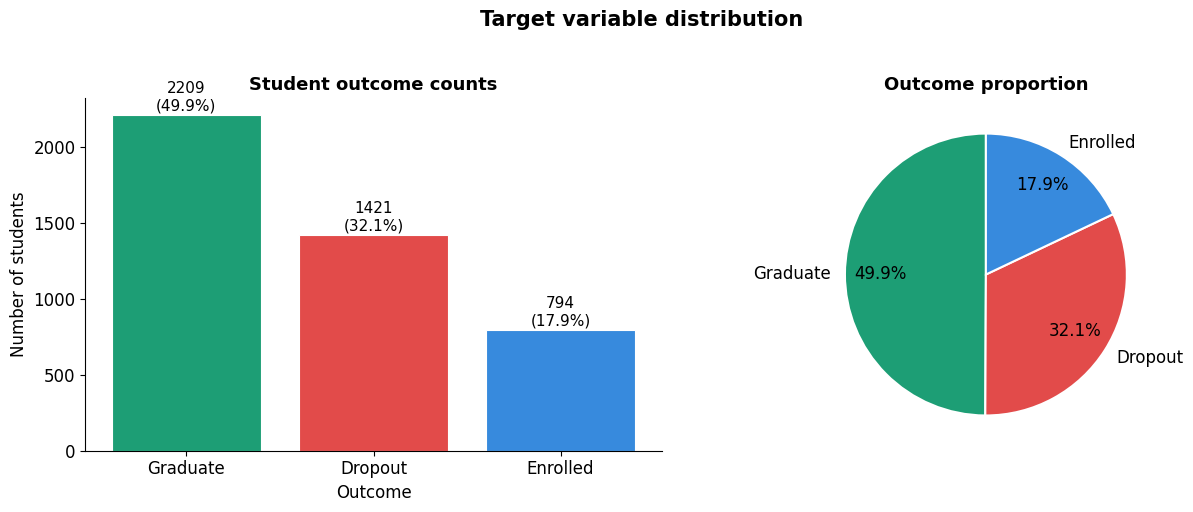


Class balance summary:
          Count  Percentage
Target                     
Graduate   2209       49.93
Dropout    1421       32.12
Enrolled    794       17.95


In [10]:
target_col = 'Target'

counts = df[target_col].value_counts()
pcts   = df[target_col].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = [PALETTE.get(c, '#888780') for c in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for i, (val, pct) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, val + 30, f'{val}\n({pct:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Student outcome counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Number of students')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Outcome proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target variable distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass balance summary:')
print(pd.DataFrame({'Count': counts, 'Percentage': pcts.round(2)}))

In [11]:
# Create binary target for modelling (used later)
df['Dropout_Binary'] = (df[target_col] == 'Dropout').astype(int)

dropout_rate = df['Dropout_Binary'].mean() * 100
print(f'Overall dropout rate : {dropout_rate:.1f}%')
print(f'Class imbalance ratio : 1 : {(1 - df["Dropout_Binary"].mean()) / df["Dropout_Binary"].mean():.2f}  (Dropout : Non-dropout)')

Overall dropout rate : 32.1%
Class imbalance ratio : 1 : 2.11  (Dropout : Non-dropout)


---
## 5. Demographic Features Analysis

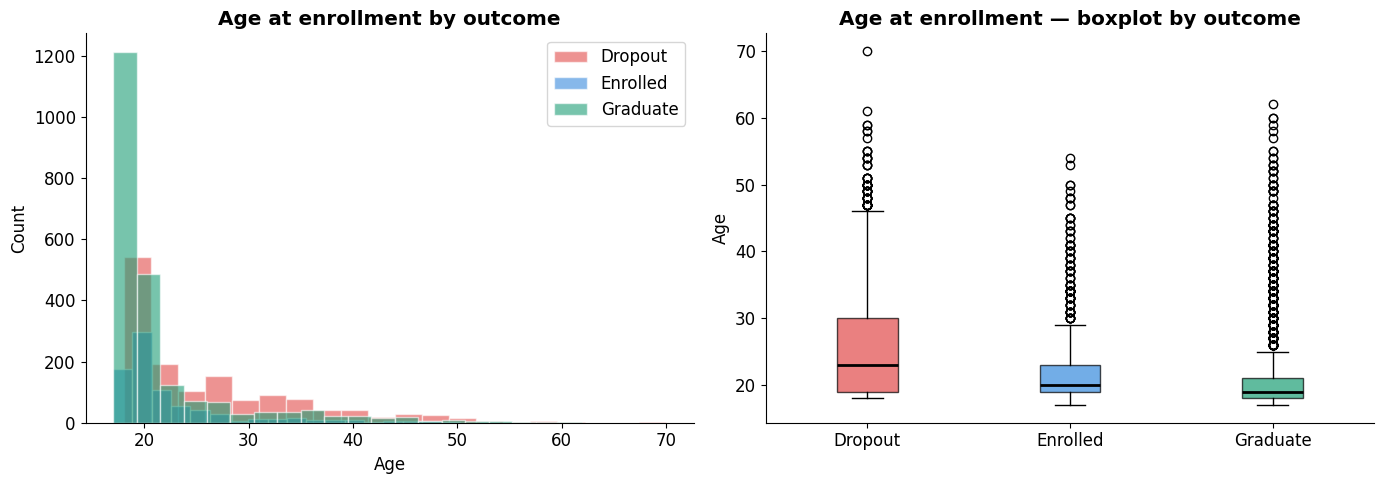

In [12]:
# ── 5a. Age at enrollment distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for outcome, color in PALETTE.items():
    subset = df[df[target_col] == outcome]['Age at enrollment']
    axes[0].hist(subset, bins=20, alpha=0.6, label=outcome, color=color, edgecolor='white')

axes[0].set_title('Age at enrollment by outcome', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot
order = ['Dropout', 'Enrolled', 'Graduate']
bp_data = [df[df[target_col] == o]['Age at enrollment'] for o in order]
bp = axes[1].boxplot(bp_data, labels=order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, outcome in zip(bp['boxes'], order):
    patch.set_facecolor(PALETTE[outcome])
    patch.set_alpha(0.7)
axes[1].set_title('Age at enrollment — boxplot by outcome', fontweight='bold')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

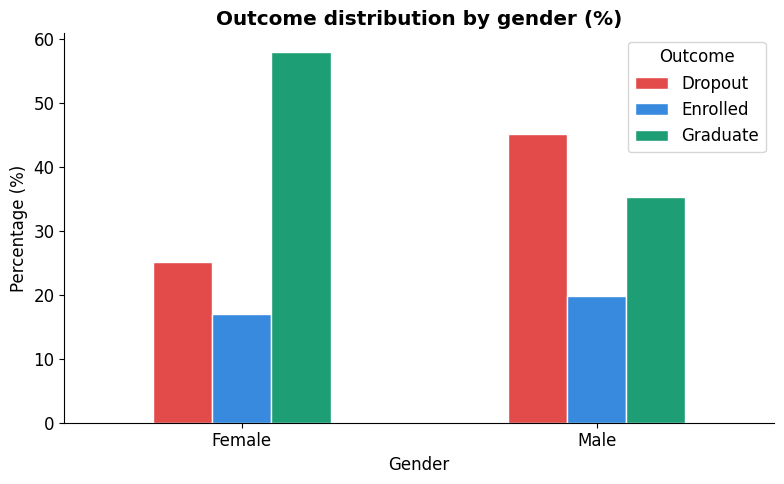

Target        Dropout  Enrolled  Graduate
Gender_Label                             
Female           25.1      17.0      57.9
Male             45.1      19.7      35.2


In [13]:
# ── 5b. Gender ────────────────────────────────────────────────────────────────
gender_map = {1: 'Male', 0: 'Female'}
df['Gender_Label'] = df['Gender'].map(gender_map)

gender_outcome = pd.crosstab(df['Gender_Label'], df[target_col], normalize='index') * 100

gender_outcome[['Dropout', 'Enrolled', 'Graduate']].plot(
    kind='bar', color=[PALETTE['Dropout'], PALETTE['Enrolled'], PALETTE['Graduate']],
    edgecolor='white', figsize=(8, 5)
)
plt.title('Outcome distribution by gender (%)', fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.tight_layout()
plt.savefig('gender_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print(gender_outcome.round(1))

In [14]:
# ── 5c. Marital status ────────────────────────────────────────────────────────
marital_map = {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced', 5: 'Facto union', 6: 'Separated'}
df['Marital_Label'] = df['Marital status'].map(marital_map)

marital_dropout = df.groupby('Marital_Label')['Dropout_Binary'].mean().sort_values(ascending=False) * 100

ax = marital_dropout.plot(kind='bar', color='#E24B4A', edgecolor='white', figsize=(10, 5), alpha=0.85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.title('Dropout rate by marital status', fontweight='bold')
plt.xlabel('Marital status')
plt.ylabel('Dropout rate (%)')
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(marital_dropout.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('marital_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

KeyError: 'Marital status'

---
## 6. Socioeconomic Features Analysis

In [ ]:
# ── 6a. Scholarship, Debtor, Tuition fees paid ────────────────────────────────
binary_socio_cols = {
    'Scholarship holder': 'Scholarship holder',
    'Debtor': 'Debtor',
    'Tuition fees up to date': 'Tuition fees up to date'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, binary_socio_cols.items()):
    ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
    ct = ct.reindex(columns=['Dropout', 'Enrolled', 'Graduate'])
    ct.index = ['No', 'Yes']
    ct.plot(kind='bar', ax=ax,
            color=[PALETTE['Dropout'], PALETTE['Enrolled'], PALETTE['Graduate']],
            edgecolor='white', alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xticklabels(['No', 'Yes'], rotation=0)
    ax.legend(title='Outcome', fontsize=9)

plt.suptitle('Outcome distribution by key socioeconomic flags', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('socioeconomic_flags.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Academic Performance Analysis

In [ ]:
# ── 7a. Grades Semester 1 & 2 ────────────────────────────────────────────────
grade_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, grade_cols):
    for outcome, color in PALETTE.items():
        subset = df[df[target_col] == outcome][col]
        ax.hist(subset[subset > 0], bins=25, alpha=0.55, label=outcome,
                color=color, edgecolor='white', density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Grade')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Grade distributions by outcome (excluding 0-grade students)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grade_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 7b. Units approved vs enrolled — dropout signal ──────────────────────────
df['Approval_Rate_Sem1'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'],
    np.nan
)
df['Approval_Rate_Sem2'] = np.where(
    df['Curricular units 2nd sem (enrolled)'] > 0,
    df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'],
    np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ['Approval_Rate_Sem1', 'Approval_Rate_Sem2'],
    ['Approval rate — Semester 1', 'Approval rate — Semester 2']):
    for outcome, color in PALETTE.items():
        subset = df[df[target_col] == outcome][col].dropna()
        ax.hist(subset, bins=20, alpha=0.55, label=outcome, color=color,
                edgecolor='white', density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Approval rate (0 = all failed, 1 = all passed)')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Unit approval rates by outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('approval_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean approval rate by outcome:')
print(df.groupby(target_col)[['Approval_Rate_Sem1', 'Approval_Rate_Sem2']].mean().round(3))

In [ ]:
# ── 7c. Curricular units approved — semester 1 vs 2 scatter ──────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for outcome, color in PALETTE.items():
    subset = df[df[target_col] == outcome]
    ax.scatter(
        subset['Curricular units 1st sem (approved)'],
        subset['Curricular units 2nd sem (approved)'],
        alpha=0.3, s=18, color=color, label=outcome
    )

ax.set_xlabel('Units approved — Semester 1')
ax.set_ylabel('Units approved — Semester 2')
ax.set_title('Units approved: Semester 1 vs 2 by outcome', fontweight='bold')
ax.legend(title='Outcome', markerscale=2)
plt.tight_layout()
plt.savefig('units_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Macroeconomic Features Analysis

In [ ]:
macro_cols = ['Unemployment rate', 'Inflation rate', 'GDP']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, macro_cols):
    bp_data = [df[df[target_col] == o][col] for o in ['Dropout', 'Enrolled', 'Graduate']]
    bp = ax.boxplot(bp_data, labels=['Dropout', 'Enrolled', 'Graduate'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch, outcome in zip(bp['boxes'], ['Dropout', 'Enrolled', 'Graduate']):
        patch.set_facecolor(PALETTE[outcome])
        patch.set_alpha(0.7)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Macroeconomic context by student outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('macroeconomic_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Parental Education & Occupation

In [ ]:
# Dropout rate by father's education level
father_edu_dropout = df.groupby("Father's qualification")['Dropout_Binary'].mean().sort_values(ascending=False) * 100
mother_edu_dropout = df.groupby("Mother's qualification")['Dropout_Binary'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

father_edu_dropout.head(10).plot(kind='bar', ax=axes[0], color='#378ADD', edgecolor='white', alpha=0.85)
axes[0].set_title("Dropout rate by father's qualification (top 10)", fontweight='bold')
axes[0].set_xlabel('Qualification code')
axes[0].set_ylabel('Dropout rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=45)

mother_edu_dropout.head(10).plot(kind='bar', ax=axes[1], color='#D4537E', edgecolor='white', alpha=0.85)
axes[1].set_title("Dropout rate by mother's qualification (top 10)", fontweight='bold')
axes[1].set_xlabel('Qualification code')
axes[1].set_ylabel('Dropout rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Parental education and dropout risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('parental_education.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Correlation Analysis

In [ ]:
# ── 10a. Correlation heatmap (numerical features only) ────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# remove helper columns
num_cols = [c for c in num_cols if c not in ['Gender_Label', 'Marital_Label']]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdBu_r', center=0,
    annot=False, linewidths=0.3, square=False,
    vmin=-1, vmax=1, ax=ax
)
ax.set_title('Feature correlation matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 10b. Top features correlated with dropout ─────────────────────────────────
corr_with_target = df[num_cols].corr()['Dropout_Binary'].drop('Dropout_Binary')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

top_n = 20
top_features = corr_sorted.head(top_n)
colors = ['#E24B4A' if corr_with_target[f] > 0 else '#378ADD' for f in top_features.index]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Absolute correlation with dropout')
ax.set_title(f'Top {top_n} features correlated with dropout (|r|)', fontweight='bold')

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#E24B4A', label='Positive correlation (↑ = more dropout)'),
    Patch(color='#378ADD', label='Negative correlation (↑ = less dropout)')
], loc='lower right')

plt.tight_layout()
plt.savefig('top_features_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 features by correlation with dropout:')
print(corr_with_target[top_features.index].round(4).to_frame('Correlation'))

---
## 11. Displaced Students & Geographic Proxy

In [ ]:
displaced_outcome = pd.crosstab(df['Displaced'], df[target_col], normalize='index') * 100
displaced_outcome.index = ['Not displaced', 'Displaced']

displaced_outcome[['Dropout', 'Enrolled', 'Graduate']].plot(
    kind='bar',
    color=[PALETTE['Dropout'], PALETTE['Enrolled'], PALETTE['Graduate']],
    edgecolor='white', figsize=(8, 5), alpha=0.85
)
plt.title('Outcome distribution — displaced vs non-displaced students', fontweight='bold')
plt.xlabel('Displacement status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.tight_layout()
plt.savefig('displaced_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print(displaced_outcome.round(1))

---
## 12. Course & Enrollment Mode Analysis

In [ ]:
# ── 12a. Daytime vs Evening dropout rate ─────────────────────────────────────
daytime_map = {1: 'Daytime', 0: 'Evening'}
df['Attendance_Mode'] = df['Daytime/evening attendance\t'].map(daytime_map)

daytime_outcome = pd.crosstab(df['Attendance_Mode'], df[target_col], normalize='index') * 100

daytime_outcome[['Dropout', 'Enrolled', 'Graduate']].plot(
    kind='bar',
    color=[PALETTE['Dropout'], PALETTE['Enrolled'], PALETTE['Graduate']],
    edgecolor='white', figsize=(8, 5), alpha=0.85
)
plt.title('Outcome by attendance mode', fontweight='bold')
plt.xlabel('Attendance mode')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.tight_layout()
plt.savefig('attendance_mode.png', dpi=150, bbox_inches='tight')
plt.show()

print(daytime_outcome.round(1))

In [ ]:
# ── 12b. Dropout rate by course ───────────────────────────────────────────────
course_stats = df.groupby('Course').agg(
    total=('Dropout_Binary', 'count'),
    dropout_rate=('Dropout_Binary', 'mean')
).sort_values('dropout_rate', ascending=False)

course_stats['dropout_rate_pct'] = course_stats['dropout_rate'] * 100

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(course_stats.index.astype(str), course_stats['dropout_rate_pct'],
              color='#E24B4A', edgecolor='white', alpha=0.8)
ax.set_xlabel('Course code')
ax.set_ylabel('Dropout rate (%)')
ax.set_title('Dropout rate by course', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('dropout_by_course.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Engineered Feature Preview

These derived features will be used in the modelling notebook.

In [ ]:
# Preview engineered features that will be created in the preprocessing notebook
df['Grade_Drop'] = (
    df['Curricular units 1st sem (grade)'] - df['Curricular units 2nd sem (grade)']
)
df['Total_Units_Failed'] = (
    (df['Curricular units 1st sem (enrolled)'] - df['Curricular units 1st sem (approved)']) +
    (df['Curricular units 2nd sem (enrolled)'] - df['Curricular units 2nd sem (approved)'])
)
df['Financial_Risk'] = (
    df['Debtor'].astype(int) + (1 - df['Tuition fees up to date'].astype(int))
)

# Boxplot of engineered features by outcome
eng_features = ['Grade_Drop', 'Total_Units_Failed', 'Financial_Risk']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, eng_features):
    bp_data = [df[df[target_col] == o][feat] for o in ['Dropout', 'Enrolled', 'Graduate']]
    bp = ax.boxplot(bp_data, labels=['Dropout', 'Enrolled', 'Graduate'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch, outcome in zip(bp['boxes'], ['Dropout', 'Enrolled', 'Graduate']):
        patch.set_facecolor(PALETTE[outcome])
        patch.set_alpha(0.7)
    ax.set_title(feat.replace('_', ' '), fontweight='bold')

plt.suptitle('Engineered features by outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. EDA Summary & Key Findings

In [ ]:
print('=' * 60)
print('  EDA SUMMARY — KEY FINDINGS')
print('=' * 60)

print(f"""
Dataset
-------
  Total students     : {len(df):,}
  Total features     : {df.shape[1]}
  Missing values     : {df.isnull().sum().sum()}

Class Distribution
------------------
  Dropout    : {(df[target_col] == 'Dropout').sum():,}  ({(df[target_col] == 'Dropout').mean()*100:.1f}%)
  Enrolled   : {(df[target_col] == 'Enrolled').sum():,}  ({(df[target_col] == 'Enrolled').mean()*100:.1f}%)
  Graduate   : {(df[target_col] == 'Graduate').sum():,}  ({(df[target_col] == 'Graduate').mean()*100:.1f}%)

Academic Signal
---------------
  Avg grade sem 1 (Dropout)   : {df[df[target_col]=='Dropout']['Curricular units 1st sem (grade)'].mean():.2f}
  Avg grade sem 1 (Graduate)  : {df[df[target_col]=='Graduate']['Curricular units 1st sem (grade)'].mean():.2f}
  Avg approval rate (Dropout) : {df[df[target_col]=='Dropout']['Approval_Rate_Sem1'].mean():.2f}
  Avg approval rate (Graduate): {df[df[target_col]=='Graduate']['Approval_Rate_Sem1'].mean():.2f}

Financial Signal
----------------
  Dropout rate (debtor)         : {df[df['Debtor']==1]['Dropout_Binary'].mean()*100:.1f}%
  Dropout rate (non-debtor)     : {df[df['Debtor']==0]['Dropout_Binary'].mean()*100:.1f}%
  Dropout rate (fees overdue)   : {df[df['Tuition fees up to date']==0]['Dropout_Binary'].mean()*100:.1f}%
  Dropout rate (fees paid)      : {df[df['Tuition fees up to date']==1]['Dropout_Binary'].mean()*100:.1f}%

Top Correlated Features with Dropout
-------------------------------------""")

print(corr_with_target[top_features.index[:8]].round(4).to_string())

print("""
Next Steps
----------
  -> Notebook 02: Preprocessing (encoding, scaling, feature engineering)
  -> Notebook 03: XGBoost model training and evaluation
  -> Notebook 04: SHAP analysis and feature importance
""")
print('=' * 60)

---
## 15. Save Processed EDA DataFrame

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/eda_output.csv', index=False)
print('EDA dataframe saved to ../data/processed/eda_output.csv')
print(f'Shape: {df.shape}')